In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import random
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

mean = [0.4914, 0.4822, 0.4465]
std = [0.2023, 0.1994, 0.2010]
config = {
    'MNIST': {
        'input_channels': 1,
        'input_size': 28,
        'num_classes': 10,
        'train_transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ]),
        'val_transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ]),
        'mean': (0.1307,),
        'std': (0.3081,),
        'cls_epochs': 25
    },
    'CIFAR10': {
        'input_channels': 3,
        'input_size': 32,
        'num_classes': 10,
        'train_transform': transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]),
        'val_transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]),
        'mean': (0.4914, 0.4822, 0.4465),
        'std': (0.2023, 0.1994, 0.2010),
        'cls_epochs': 20
    }
}

m_cfg = config['MNIST']
c_cfg = config['CIFAR10']

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

In [2]:
def load_dataset(dataset_name):
    cfg = config[dataset_name]
    
    if dataset_name == 'MNIST':
        train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=cfg['train_transform'])
        test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=cfg['val_transform'])
    elif dataset_name == 'CIFAR10':
        train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=cfg['train_transform'])
        test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=cfg['val_transform'])
    
    # Split train into train and validation
    train_size = len(train_dataset) - 10000
    train_dataset, val_dataset = random_split(train_dataset, [train_size, 10000])
    
    # Apply validation transform to the validation dataset
    val_dataset.dataset.transform = cfg['val_transform']
    
    return train_dataset, val_dataset, test_dataset

def create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size):
    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    )


In [3]:
class Classifier(nn.Module):
    def __init__(self, input_channels, flattened_size):
        super(Classifier, self).__init__()
        self.encoder = nn.Sequential( 
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.35),
            nn.Flatten(), 
            nn.Linear(flattened_size, 128)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.classifier(x)
        return x

In [4]:
def train_classifier(model, train_loader, val_loader, device, num_epochs=15):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)
    best_acc = 0.0
    patience_counter = 0
    patience_limit = 10

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss, total, correct = 0.0, 0, 0
        for inputs, labels in tqdm(train_loader, desc=f"CLS Epoch {epoch+1}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = 100 * correct / total
        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(train_acc)
        
        # Validation phase
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(val_acc)
        
        print(f'CLS Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%'
              f', Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_acc:.2f}%')
        
        # Scheduler step
        scheduler.step(val_acc)
        
        # Early stopping
        if val_acc > best_acc:
            best_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience_limit:
                print("Early stopping triggered.")
                break
    
    plot_losses(train_losses, val_losses, 'Classifier Losses')
    plot_losses(train_accuracies, val_accuracies, 'Classifier Accuracies', 'accuracy')
    
    return model

def evaluate_classifier(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

def plot_losses(train_losses, val_losses, title, objective='loss'):
    plt.figure()
    plt.plot(train_losses, label=f'Train {objective}')
    plt.plot(val_losses, label=f'Validation {objective}')
    plt.xlabel('Epoch')
    plt.ylabel(f'{objective.capitalize()}')
    plt.title(title)
    plt.legend()
    plt.show()

In [5]:
# Model instantiation
input_dim = 3072  # For CIFAR-10
latent_dim = 128
num_classes = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:

# Data preparation (example for CIFAR-10)
mean = [0.4914, 0.4822, 0.4465]
std = [0.2023, 0.1994, 0.2010]
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

set_seed(42)
batch_size=128
dataset_name = "CIFAR10"
cfg = config[dataset_name]
train_dataset, val_dataset, test_dataset = load_dataset(dataset_name)
train_loader, val_loader, test_loader = create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size)

Files already downloaded and verified
Files already downloaded and verified


In [7]:
model = Classifier(input_channels=c_cfg['input_channels'], flattened_size=(64*8*8)).to(device)
print(model)

Classifier(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Dropout2d(p=0.35, inplace=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=4096, out_features=128, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10,

CLS Epoch 1: 100%|██████████| 313/313 [00:22<00:00, 13.76it/s]


CLS Epoch [1/20] Train Loss: 1.5101, Train Acc: 45.53%, Val Loss: 1.1682, Val Acc: 58.14%


CLS Epoch 2: 100%|██████████| 313/313 [00:18<00:00, 16.60it/s]


CLS Epoch [2/20] Train Loss: 1.1867, Train Acc: 57.87%, Val Loss: 1.0061, Val Acc: 64.44%


CLS Epoch 3: 100%|██████████| 313/313 [00:23<00:00, 13.51it/s]


...

CLS Epoch [18/20] Train Loss: 0.6296, Train Acc: 77.75%, Val Loss: 0.7372, Val Acc: 73.82%


CLS Epoch 19: 100%|██████████| 313/313 [00:16<00:00, 19.49it/s]


CLS Epoch [19/20] Train Loss: 0.6170, Train Acc: 78.29%, Val Loss: 0.7344, Val Acc: 74.18%


CLS Epoch 20: 100%|██████████| 313/313 [00:15<00:00, 19.74it/s]


CLS Epoch [20/20] Train Loss: 0.6124, Train Acc: 78.38%, Val Loss: 0.7384, Val Acc: 73.99%


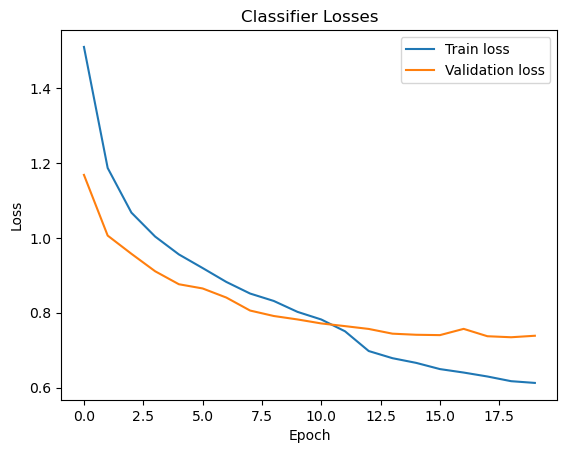

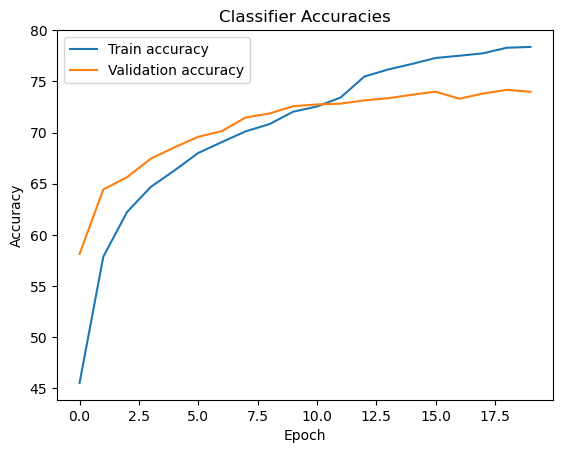

In [8]:
# Train the model
model = train_classifier(model, train_loader, val_loader, device, num_epochs=c_cfg['cls_epochs'])

In [9]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 74.32%


In [10]:


import importlib
import utils
importlib.reload(utils)
from utils import plot_tsne
plot_tsne(model.encoder, test_loader, device)


In [ ]:
####################### MNIST

In [10]:
set_seed(42)
batch_size=128
dataset_name = "MNIST"
cfg = config[dataset_name]
train_dataset, val_dataset, test_dataset = load_dataset(dataset_name)
train_loader, val_loader, test_loader = create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size)

CLS Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

CLS Epoch 1: 100%|██████████| 391/391 [00:15<00:00, 25.33it/s]


CLS Epoch [1/15] Train Loss: 0.2457, Train Acc: 93.96%, Val Loss: 0.0634, Val Acc: 98.25%


CLS Epoch 2: 100%|██████████| 391/391 [00:15<00:00, 25.19it/s]


CLS Epoch [2/15] Train Loss: 0.0814, Train Acc: 97.67%, Val Loss: 0.0487, Val Acc: 98.57%


...

CLS Epoch [13/15] Train Loss: 0.0203, Train Acc: 99.37%, Val Loss: 0.0273, Val Acc: 99.14%


CLS Epoch 14: 100%|██████████| 391/391 [00:16<00:00, 24.01it/s]


CLS Epoch [14/15] Train Loss: 0.0174, Train Acc: 99.43%, Val Loss: 0.0266, Val Acc: 99.23%


CLS Epoch 15: 100%|██████████| 391/391 [00:16<00:00, 23.81it/s]


CLS Epoch [15/15] Train Loss: 0.0171, Train Acc: 99.46%, Val Loss: 0.0279, Val Acc: 99.16%


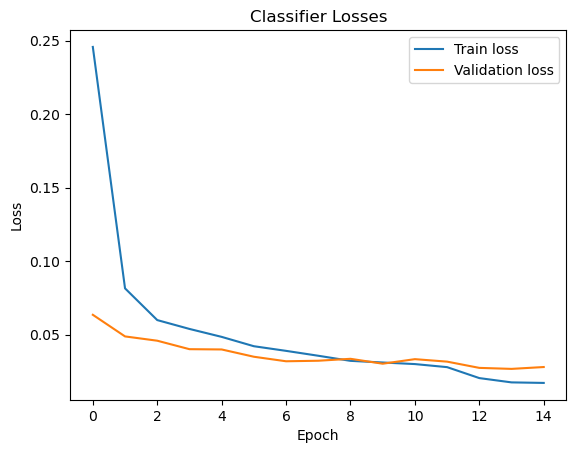

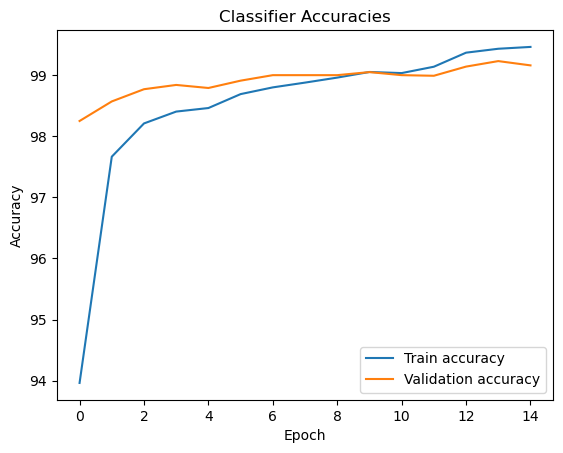

In [11]:
model = Classifier(input_channels=1, flattened_size=(64*7*7)).to(device)
model = train_classifier(model, train_loader, val_loader, device)

In [127]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 99.06%


In [ ]:
import importlib
import utils
importlib.reload(utils)
from utils import plot_tsne
plot_tsne(model.encoder, test_loader, device)
